# t1t2_component_detection — End-to-end demo

A local walk-through of the from-scratch **T1–T2 Detection Transformer**:

**protocol → signed signal → balanced n=1–4 data → model → short training → evaluation**

Runs on the small `data/dev_1to4/` split. **This is a smoke demo, not the thesis training run —
that happens on the GPU cluster.** The point is to show every piece connects, and to demonstrate
*how the results have to be read* (see §6: the aggregate number lies).

In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

# locate the repo root whether we run from notebooks/ or the package root
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "voxel_generator" / "src"))
# The config's data paths are relative to the repo root, which is where the CLI runs from.
# Match that, so the notebook exercises exactly the same paths the real runs do.
os.chdir(ROOT)
torch.manual_seed(0); np.random.seed(0)

from t1t2.device import get_device, device_info
FIG = ROOT / "results" / "demo" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
print("root  :", ROOT.name)
print("device:", get_device(None), "|", device_info())

root  : t1t2_component_detection
device: mps | mps (Apple GPU)


## 1. The acquisition protocol
The fixed 8 TI × 8 TE = 64-point scanner schedule, used exactly as stored (scanner order).

In [2]:
from t1t2.physics import load_protocol
proto = load_protocol()
print(f"{proto.n_points} points | {len(np.unique(proto.ti))} TI x {len(np.unique(proto.te))} TE | TR = {proto.tr:.0f} ms")
print("unique TI (ms):", np.round(np.unique(proto.ti), 1))
print("unique TE (ms):", np.round(np.unique(proto.te), 1))

64 points | 8 TI x 8 TE | TR = 20000 ms
unique TI (ms): [  50.   85.  143.  243.  412.  697. 1181. 2000.]
unique TE (ms): [  4.5   7.5  12.   20.   33.   55.   91.  150. ]


## 2. The dataset: balanced over compartment count

One file per compartment count, `n1 … n4`. Per-n files are what make the count distribution
**exactly** balanced rather than balanced only in expectation, and they give per-n test sets for
free. Every file carries the same 80-column schema (unused slots NaN), so the four concatenate
into one dataset.

In [3]:
import json
DEV = ROOT / "data" / "dev_1to4"
rows = []
for n in range(1, 5):
    d = pd.read_parquet(DEV / f"n{n}" / "train.parquet")
    rows.append({"file": f"n{n}/train", "rows": len(d), "n_comp": sorted(d.n_comp.unique()),
                 "cols": d.shape[1]})
print(pd.DataFrame(rows).to_string(index=False))

m = json.load(open(DEV / "n2" / "manifest.json"))
print("\nmanifest (n2) — every dataset says what it is and where it came from:")
print(f"  n_comp={m['n_comp']}  base_seed={m['base_seed']}  streams={m['streams']}")
print(f"  protocol sha256 = {m['protocol_sha256'][:32]}...")
print(f"  deps = {m['dependencies']}")

    file  rows n_comp  cols
n1/train 12500    [1]    80
n2/train 12500    [2]    80
n3/train 12500    [3]    80
n4/train 12500    [4]    80

manifest (n2) — every dataset says what it is and where it came from:
  n_comp=2  base_seed=0  streams={'params': 1001, 'noise': 2001, 'snr': 3001}
  protocol sha256 = 78ab7a82ce2c1ef91f7379a466aede34...
  deps = {'python': '3.12.2', 'numpy': '1.26.4', 'pandas': '2.2.1', 'pyarrow': '24.0.0'}


## 3. One voxel: signed signal + ground-truth compartments
The 64 scanner-ordered points folded back into an 8×8 (TI×TE) grid. Note the **negative (red)
values** — the inversion-recovery signal genuinely goes negative, which is why the data is
signed and the noise model is Gaussian, not Rician.

n_comp: 3
  comp 1: T1=   83.4 ms   T2=   7.1 ms   w=0.163
  comp 2: T1=  108.1 ms   T2=  60.1 ms   w=0.740
  comp 3: T1= 3728.1 ms   T2=  13.6 ms   w=0.098


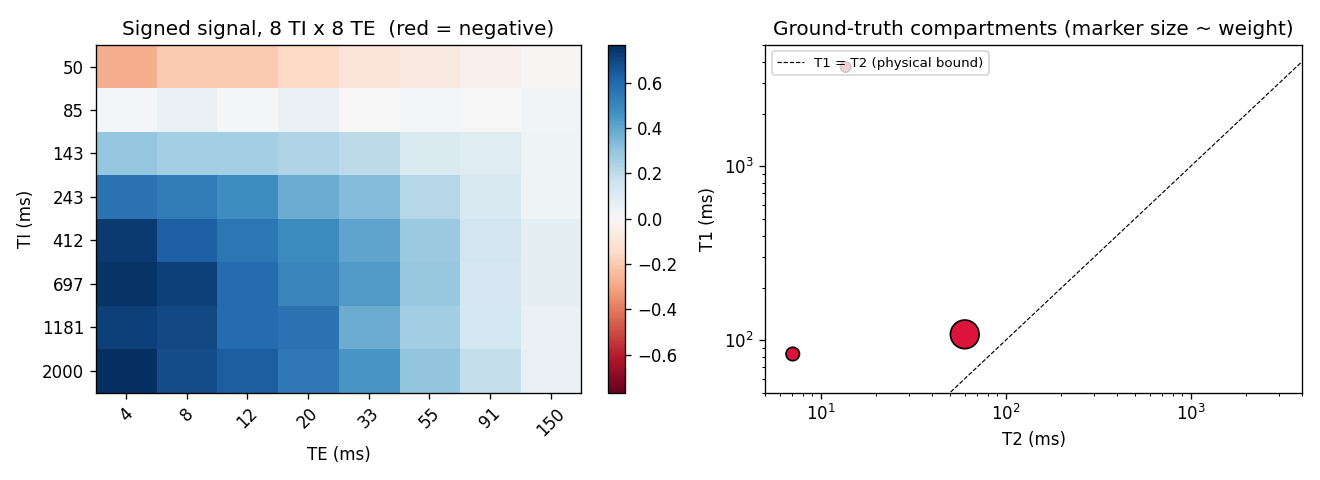

In [4]:
df = pd.read_parquet(DEV / "n3" / "train.parquet")
row = df.iloc[7]
S = row[[f"S_{i+1}" for i in range(64)]].to_numpy(float)
n = int(row.n_comp)
comps = [(row[f"T1_{i+1}"], row[f"T2_{i+1}"], row[f"w_{i+1}"]) for i in range(n)]
print("n_comp:", n)
for i, (t1, t2, w) in enumerate(comps):
    print(f"  comp {i+1}: T1={t1:7.1f} ms   T2={t2:6.1f} ms   w={w:.3f}")

uti, ute = np.unique(proto.ti), np.unique(proto.te)
img = np.full((8, 8), np.nan)
for p in range(64):
    i = int(np.argmin(abs(uti - proto.ti[p])))
    j = int(np.argmin(abs(ute - proto.te[p])))
    img[i, j] = S[p]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
mx = np.nanmax(np.abs(img))
im = ax[0].imshow(img, cmap="RdBu", vmin=-mx, vmax=mx, aspect="auto")
ax[0].set_xticks(range(8)); ax[0].set_xticklabels([f"{t:.0f}" for t in ute], rotation=45)
ax[0].set_yticks(range(8)); ax[0].set_yticklabels([f"{t:.0f}" for t in uti])
ax[0].set_xlabel("TE (ms)"); ax[0].set_ylabel("TI (ms)")
ax[0].set_title("Signed signal, 8 TI x 8 TE  (red = negative)")
fig.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].scatter([c[1] for c in comps], [c[0] for c in comps],
              s=[400 * c[2] for c in comps], c="crimson", edgecolor="k", zorder=3)
ax[1].plot([5, 4000], [5, 4000], "k--", lw=0.7, label="T1 = T2 (physical bound)")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlim(5, 4000); ax[1].set_ylim(50, 5000)
ax[1].set_xlabel("T2 (ms)"); ax[1].set_ylabel("T1 (ms)")
ax[1].set_title("Ground-truth compartments (marker size ~ weight)")
ax[1].legend(loc="upper left", fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "voxel.png", dpi=120); plt.close(fig)
from IPython.display import Image
Image(filename=str(FIG / "voxel.png"))

### Coverage: the compartments fill the feasible region

`T1 > T2` is enforced by **rejection sampling**, giving a uniform *joint* over the feasible
log-space region. The obvious shortcut — capping T2 at T1 — instead oversampled short T1 by
1.7×. Neither marginal is log-uniform: the log-T1 density is proportional to the feasible
log-T2 width at that T1, which is why the cloud thins toward the diagonal.

frac T1 < 200 ms: 0.211    (the old clipping gave ~0.314)


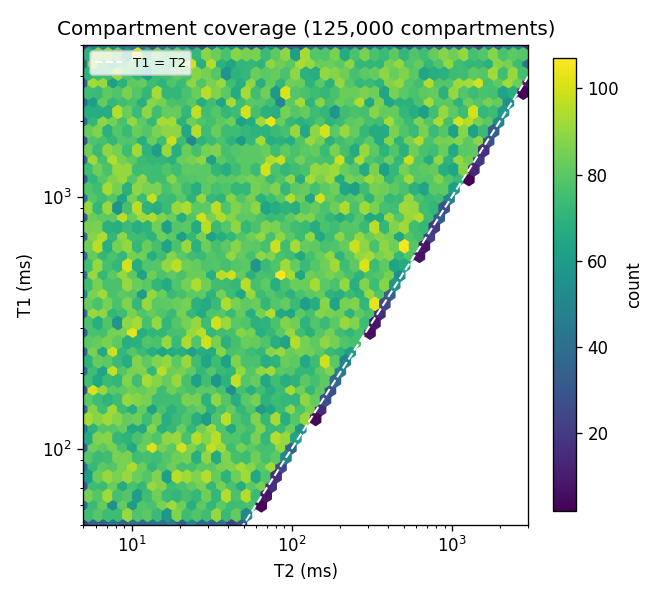

In [5]:
t1a, t2a = [], []
for n in range(1, 5):
    d = pd.read_parquet(DEV / f"n{n}" / "train.parquet")
    for i in range(n):
        t1a.append(d[f"T1_{i+1}"].dropna().to_numpy()); t2a.append(d[f"T2_{i+1}"].dropna().to_numpy())
t1a, t2a = np.concatenate(t1a), np.concatenate(t2a)

fig, ax = plt.subplots(figsize=(5.5, 5))
hb = ax.hexbin(t2a, t1a, xscale="log", yscale="log", gridsize=45, cmap="viridis", mincnt=1)
ax.plot([5, 4000], [5, 4000], "w--", lw=1.2, label="T1 = T2")
ax.set_xlim(5, 3000); ax.set_ylim(50, 4000)
ax.set_xlabel("T2 (ms)"); ax.set_ylabel("T1 (ms)")
ax.set_title(f"Compartment coverage ({len(t1a):,} compartments)")
ax.legend(loc="upper left", fontsize=8)
fig.colorbar(hb, ax=ax, fraction=0.046, label="count")
fig.tight_layout(); fig.savefig(FIG / "coverage.png", dpi=120); plt.close(fig)
print(f"frac T1 < 200 ms: {(t1a < 200).mean():.3f}    (the old clipping gave ~0.314)")
Image(filename=str(FIG / "coverage.png"))

## 4. The model
MLP encoder → 10 learned queries → transformer decoder → per-query (T1, T2, w, existence).

In [6]:
from t1t2.config import load_config
from t1t2.model import build_model
cfg = load_config(ROOT / "configs" / "baseline.yaml")
model = build_model(cfg.model)
nparams = sum(p.numel() for p in model.parameters())
print(f"T1T2DETR: {nparams/1e6:.2f}M params | {cfg.model.n_queries} queries x 4 outputs (T1, T2, w, exist)")
print(f"signal_norm={cfg.data.signal_norm!r} -> divides out M0, which is unidentifiable anyway "
      f"since the weights sum to 1")

X = torch.from_numpy(df[[f"S_{i+1}" for i in range(64)]].to_numpy(np.float32)[:4])
out = model(X)
print("forward:", tuple(X.shape), "->", tuple(out.shape), "= (batch, queries, [T1,T2,w,exist_logit])")

T1T2DETR: 4.51M params | 10 queries x 4 outputs (T1, T2, w, exist)
signal_norm='max' -> divides out M0, which is unidentifiable anyway since the weights sum to 1
forward: (4, 64) -> (4, 10, 4) = (batch, queries, [T1,T2,w,exist_logit])


## 5. Short training demo
A quick run on 2,000 voxels — just enough to watch the Hungarian loss fall. Early stopping is on,
and `train()` hands back the **best** model by validation loss, not the final epoch. The real run
uses 1M voxels on a GPU; here we only prove the loop learns.

train loss 0.175 -> 0.056   |   val loss 0.113 -> 0.068
best val 0.0560 @ epoch 14  (the returned model is that one, not the last)


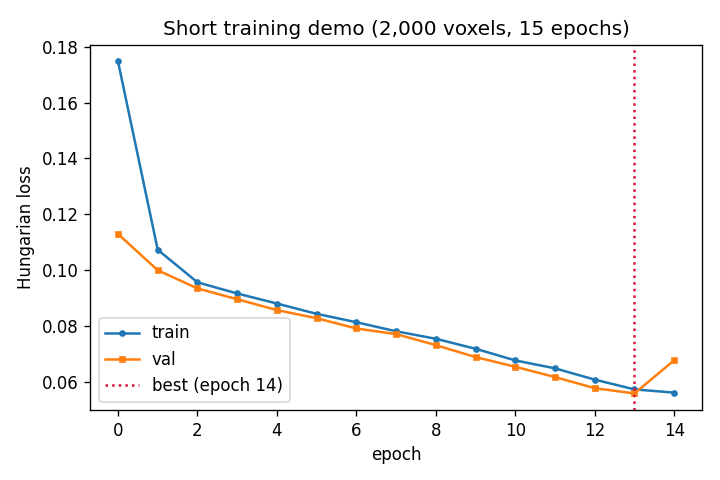

In [7]:
import copy
from t1t2.train import train

demo_cfg = copy.deepcopy(cfg)
demo_cfg.name = "demo"
hist, rd, model = train(demo_cfg, results_dir=ROOT / "results" / "demo",
                        max_epochs=15, limit=2000, resume=False, log=lambda *a: None)

tr = [h["train"]["loss"] for h in hist]
va = [h["val"]["loss"] for h in hist]
best = int(np.argmin(va))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tr, "o-", label="train", ms=3)
ax.plot(va, "s-", label="val", ms=3)
ax.axvline(best, color="crimson", ls=":", label=f"best (epoch {best+1})")
ax.set_xlabel("epoch"); ax.set_ylabel("Hungarian loss")
ax.set_title(f"Short training demo (2,000 voxels, {len(hist)} epochs)")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "loss.png", dpi=120); plt.close(fig)
print(f"train loss {tr[0]:.3f} -> {tr[-1]:.3f}   |   val loss {va[0]:.3f} -> {va[-1]:.3f}")
print(f"best val {va[best]:.4f} @ epoch {best+1}  (the returned model is that one, not the last)")
Image(filename=str(FIG / "loss.png"))

## 6. Evaluation — and why the aggregate number lies

The model is deliberately under-trained here, so the numbers are bad. That is not the point. The
point is **how they have to be read**: the data is uniform over n_comp=1…4, so a single aggregate
averages an easy regime (n=1) with a near-impossible one (n=4, where at low SNR most voxels have
a compartment below the noise floor) and describes neither.

In [8]:
from t1t2.data import VoxelDataset, TargetNormalizer
from t1t2.eval import compute_metrics, detr_predictions, scatter_figure, true_compartments

nz = TargetNormalizer.from_config(demo_cfg.data)
ds = VoxelDataset(demo_cfg.data.test_path, demo_cfg.data, nz, limit=2000)
print(f"test voxels: {len(ds)} | compartment slots inferred from the columns: {ds.max_comp}")

preds = detr_predictions(model, ds, get_device(None), nz)
trues = true_compartments(ds)
m = compute_metrics(preds, trues, n_queries=demo_cfg.model.n_queries)

print(f"\naggregate count_accuracy = {m['count_accuracy']:.3f}   <-- read the per-n table before believing this")
print(f"aggregate count_mae      = {m['count_mae']:.2f}")
print("\nper-n breakdown (mandatory):")
print(f"  {'n':>2} {'voxels':>7} {'count_acc':>10} {'count_mae':>10} {'t1_rel':>8} {'t2_rel':>8}")
for n in (1, 2, 3, 4):
    print(f"  {n:>2} {m[f'n_voxels_n{n}']:>7} {m[f'count_accuracy_n{n}']:>10.3f} "
          f"{m[f'count_mae_n{n}']:>10.2f} {m[f'n{n}_t1_rel_median']:>8.3f} {m[f'n{n}_t2_rel_median']:>8.3f}")

test voxels: 2000 | compartment slots inferred from the columns: 4



aggregate count_accuracy = 0.465   <-- read the per-n table before believing this
aggregate count_mae      = 0.74

per-n breakdown (mandatory):
   n  voxels  count_acc  count_mae   t1_rel   t2_rel
   1     500      0.810       0.35    0.069    0.079
   2     500      0.046       1.55    0.266    0.302
   3     500      0.118       0.93    0.340    0.465
   4     500      0.884       0.15    0.420    0.531


### The confusion matrix: *how* it misses, not just how often

Rows are the true count, columns what the model predicted (0–10: it has 10 queries and may keep
any number of them). This is the view that makes the trap obvious.

the model predicts 4 compartments for 58% of voxels — regardless of the truth.
so count_accuracy_n4 = 0.884 is luck, not skill.
that is exactly why the per-n table is mandatory and the aggregate is not a result.


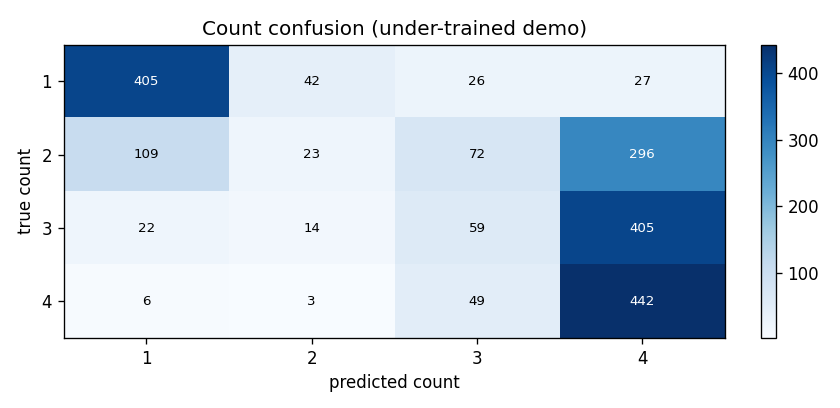

In [9]:
conf = m["confusion"]
mat = np.array([conf["matrix"][str(r)] for r in conf["true_counts"]])
keep = mat.sum(axis=0) > 0                      # only show columns that ever occur
sub = mat[:, keep]

fig, ax = plt.subplots(figsize=(7, 3.4))
im = ax.imshow(sub, cmap="Blues", aspect="auto")
ax.set_xticks(range(keep.sum())); ax.set_xticklabels(np.arange(mat.shape[1])[keep])
ax.set_yticks(range(len(conf["true_counts"]))); ax.set_yticklabels(conf["true_counts"])
ax.set_xlabel("predicted count"); ax.set_ylabel("true count")
ax.set_title("Count confusion (under-trained demo)")
for i in range(sub.shape[0]):
    for j in range(sub.shape[1]):
        if sub[i, j]:
            ax.text(j, i, str(sub[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if sub[i, j] > sub.max() * 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout(); fig.savefig(FIG / "confusion.png", dpi=120); plt.close(fig)

pc = np.array([len(p) for p in preds])
mode = int(np.bincount(pc).argmax())
print(f"the model predicts {mode} compartments for {(pc == mode).mean()*100:.0f}% of voxels — "
      f"regardless of the truth.")
print(f"so count_accuracy_n{mode} = {m.get(f'count_accuracy_n{mode}', float('nan')):.3f} is luck, not skill.")
print("that is exactly why the per-n table is mandatory and the aggregate is not a result.")
Image(filename=str(FIG / "confusion.png"))

### Physics checks: do the outputs make sense?

The T1/T2/weight heads are independent sigmoids, so nothing *stops* the model emitting T2 ≥ T1 or
weights that miss 1. Nothing is post-processed away — we measure it instead. This is the concrete
form of thesis goal 1's "outputs make physical sense".

T2 >= T1 violation rate : 0.0020   (physically impossible)
|sum(active w) - 1| med : 0.1646   (should approach 0)

regression, reported two ways:
  all matched pairs    : t1_rel=0.312  (4760 pairs)
  count-correct voxels : t1_rel=0.320  (929 voxels)
  the second is conditioned on success — an easier subset, NOT random-voxel performance.
  an undercounting model only reports what it found, which flatters its matched errors;
  the two together bracket that bias.


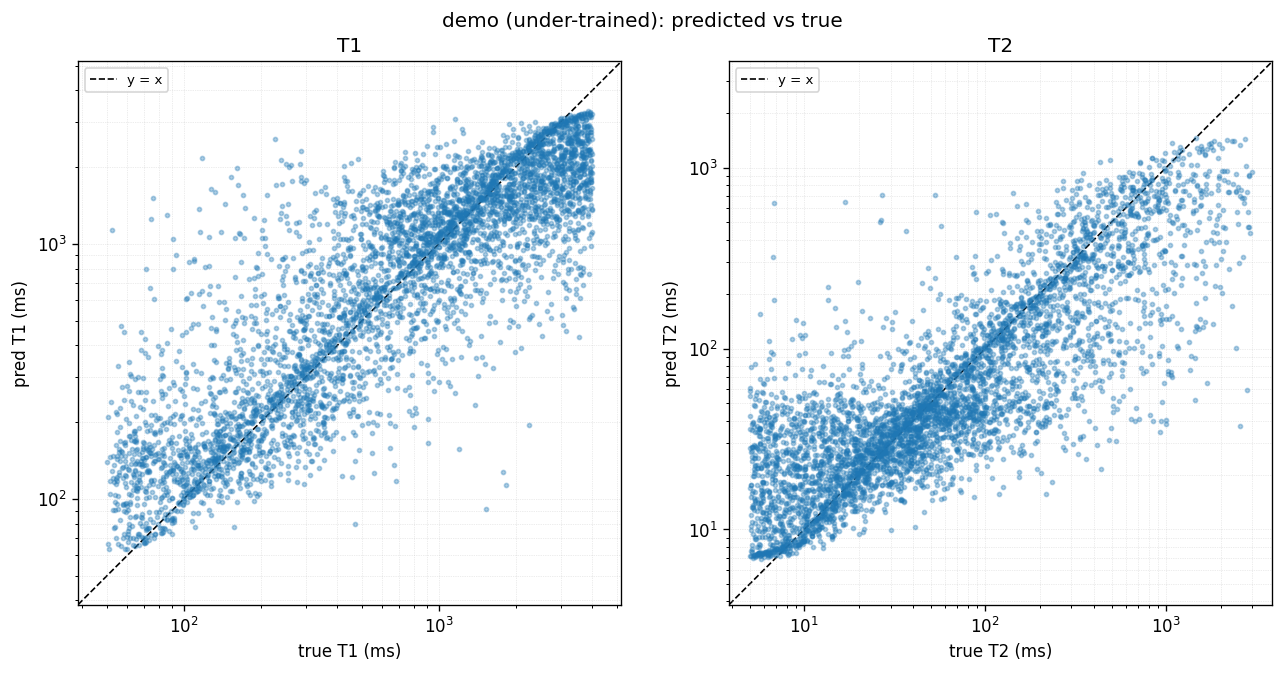

In [10]:
print(f"T2 >= T1 violation rate : {m['t2_ge_t1_rate']:.4f}   (physically impossible)")
print(f"|sum(active w) - 1| med : {m['weight_sum_dev_median']:.4f}   (should approach 0)")
print()
print("regression, reported two ways:")
print(f"  all matched pairs    : t1_rel={m['t1_rel_median']:.3f}  ({m['n_matched']} pairs)")
print(f"  count-correct voxels : t1_rel={m['cc_t1_rel_median']:.3f}  ({m['cc_n_voxels']} voxels)")
print("  the second is conditioned on success — an easier subset, NOT random-voxel performance.")
print("  an undercounting model only reports what it found, which flatters its matched errors;")
print("  the two together bracket that bias.")

path = scatter_figure(preds, trues, FIG / "scatter_demo.png",
                      title="demo (under-trained): predicted vs true")
Image(filename=str(path))

## 7. Predicted vs ground truth, overlaid in (T1, T2)
Are the **red** predicted markers (existence > 0.5) near the **black** true ones? **Grey ×** are
queries the model rejected; red numbers are existence probabilities; marker size ~ weight.

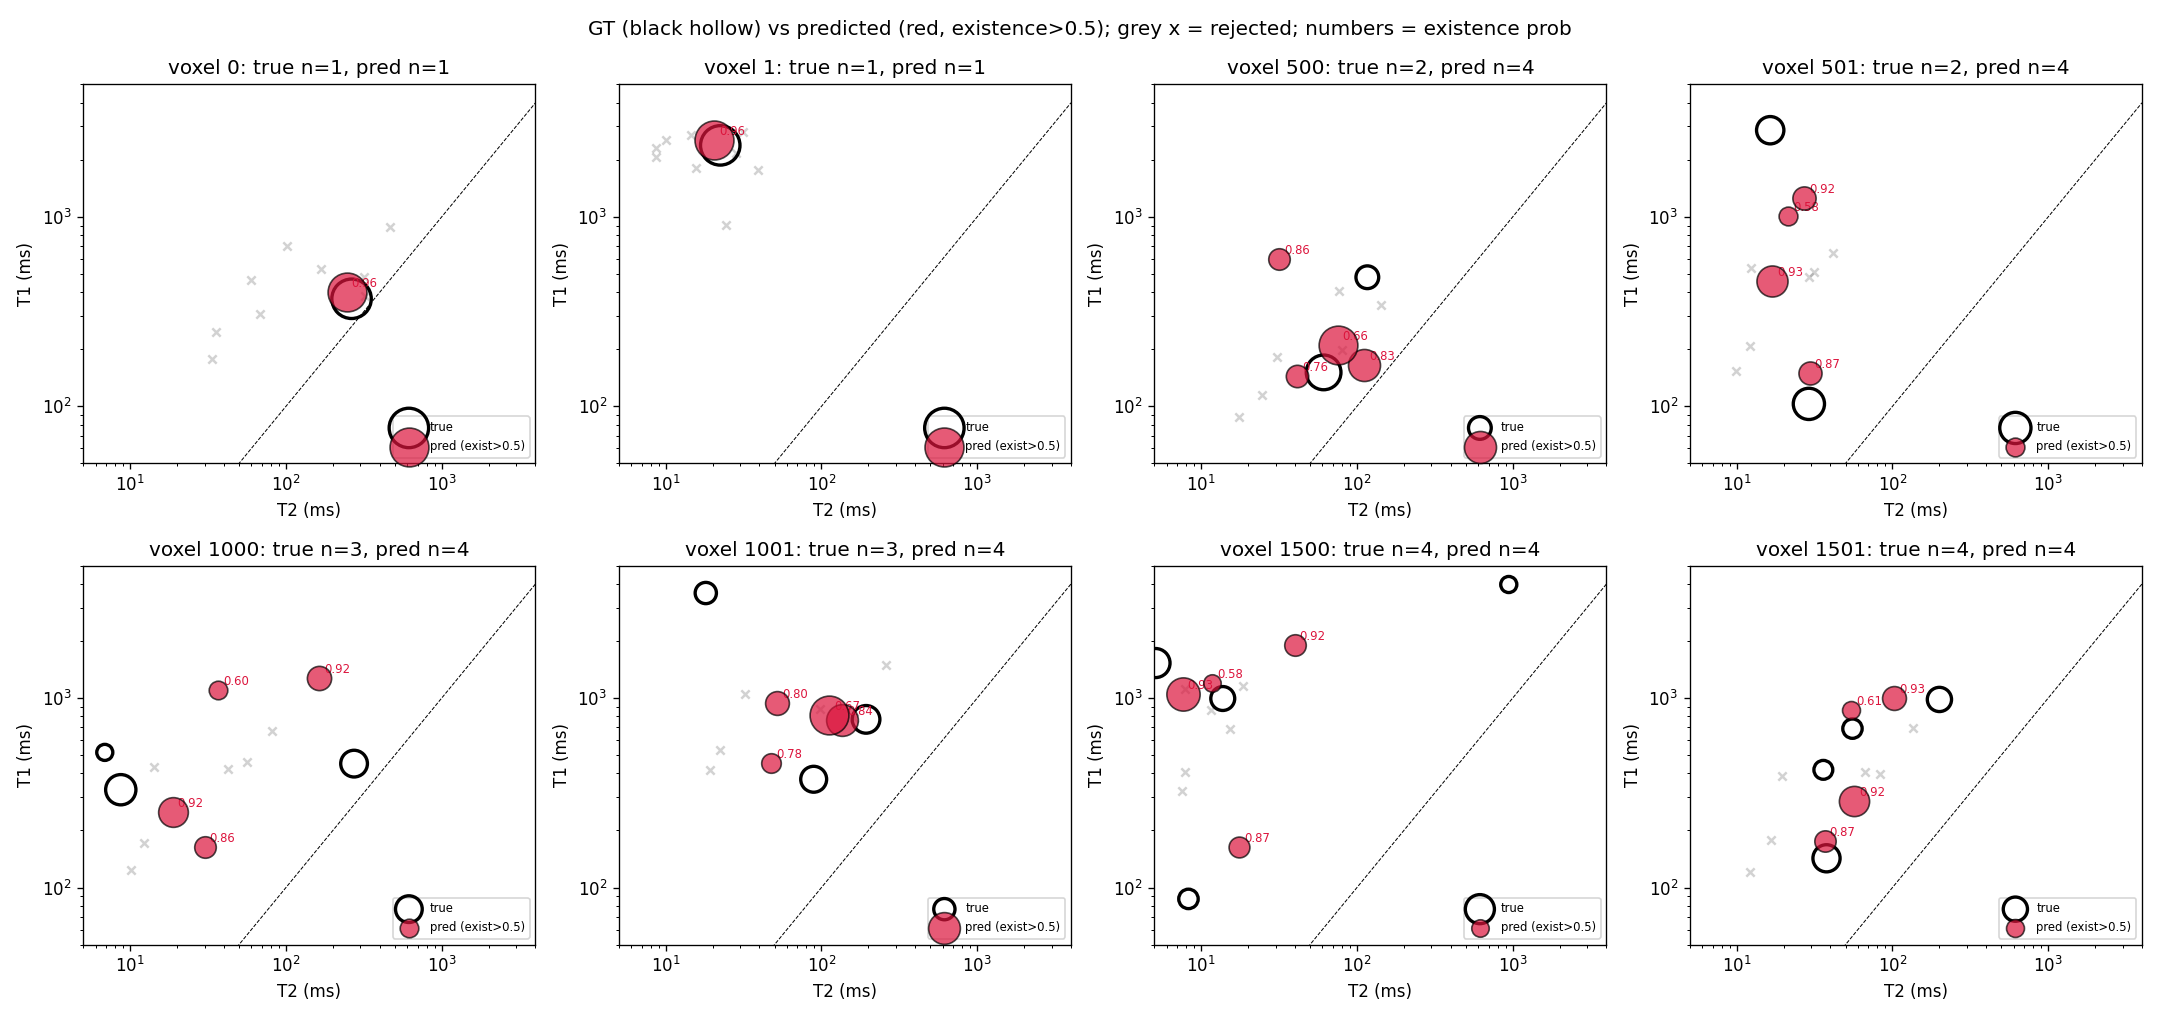

In [11]:
dev = get_device(None)
with torch.no_grad():
    raw = model(ds.X.to(dev)).cpu().numpy()
exist = 1.0 / (1.0 + np.exp(-raw[:, :, 3]))
t1p = nz.denormalize_t1(raw[:, :, 0]); t2p = nz.denormalize_t2(raw[:, :, 1]); wp = raw[:, :, 2]
nc = ds.n_comp.numpy()

idxs = []
for tn in (1, 2, 3, 4):
    idxs += np.where(nc == tn)[0][:2].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for ax, i in zip(axes.ravel(), idxs):
    keep = exist[i] > 0.5
    for j in range(int(nc[i])):
        ax.scatter(ds.raw_t2[i, j], ds.raw_t1[i, j], s=60 + 500 * ds.raw_w[i, j],
                   facecolors="none", edgecolors="black", linewidths=2, zorder=3,
                   label="true" if j == 0 else None)
    kq = np.where(keep)[0]
    for q in kq:
        ax.scatter(t2p[i, q], t1p[i, q], s=60 + 500 * wp[i, q], c="crimson", alpha=0.7,
                   edgecolors="k", zorder=4, label="pred (exist>0.5)" if q == kq[0] else None)
        ax.annotate(f"{exist[i, q]:.2f}", (t2p[i, q], t1p[i, q]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points", color="crimson")
    for q in np.where(~keep)[0]:
        ax.scatter(t2p[i, q], t1p[i, q], s=25, c="grey", alpha=0.35, marker="x", zorder=2)
    ax.plot([5, 4000], [5, 4000], "k--", lw=0.6)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(5, 4000); ax.set_ylim(50, 5000)
    ax.set_xlabel("T2 (ms)"); ax.set_ylabel("T1 (ms)")
    ax.set_title(f"voxel {i}: true n={int(nc[i])}, pred n={int(keep.sum())}")
    ax.legend(loc="lower right", fontsize=7)
fig.suptitle("GT (black hollow) vs predicted (red, existence>0.5); grey x = rejected; numbers = existence prob")
fig.tight_layout()
# an earlier cell imported eval, which puts matplotlib on the Agg backend, so plt.show() would
# render nothing here — save and display instead.
fig.savefig(FIG / "overlay_pred_vs_true.png", dpi=120); plt.close(fig)
Image(filename=str(FIG / "overlay_pred_vs_true.png"))

## Summary
- The pipeline runs end to end: **protocol → signed 64-pt signal → DETR → Hungarian loss → evaluation**.
- The forward model matches the data generator bit-for-bit (parity-tested), so the training targets
  and the physics speak exactly the same language.
- The data is **balanced over n_comp = 1…4** with uniform joint (T1, T2) coverage, and every dataset
  carries a manifest pinning its seeds, protocol checksum and dependency versions.
- **Read results per-n.** The aggregate over a uniform n=1…4 mix is not interpretable on its own,
  and it is not comparable to the older 20/60/20 n≤3 numbers — that is a different distribution.
- **Next:** full generation (250k × 4 = 1M) on the cluster → the data-audit gate → full training.